<a href="https://colab.research.google.com/github/kamal-gavel/NATURAL-LANGUAGE-PROCESSING-IMPLEMENTATION-IN-FINANCE-/blob/main/VANISHING_GRADIENT_DEMO_(SIGMOID_vs_RELU).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

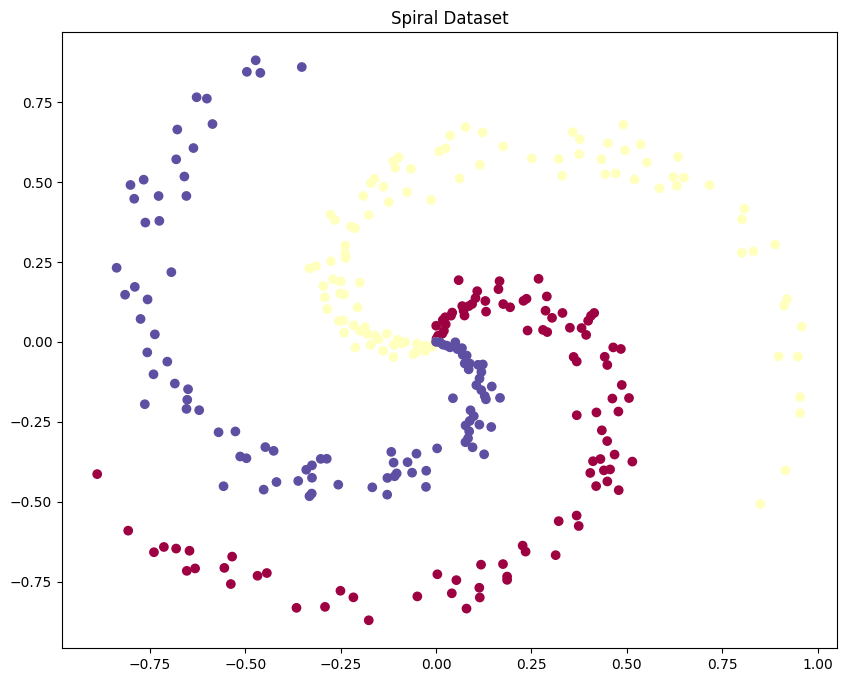

[SIGM] Iter 0, Loss: 1.1564
[SIGM] Iter 2000, Loss: 0.5169
[SIGM] Iter 4000, Loss: 0.4873
[SIGM] Iter 6000, Loss: 0.4792
[SIGM] Iter 8000, Loss: 0.4699
[SIGM] Iter 10000, Loss: 0.4697
[SIGM] Iter 12000, Loss: 0.4651
[SIGM] Iter 14000, Loss: 0.4626
[SIGM] Iter 16000, Loss: 0.4612
[SIGM] Iter 18000, Loss: 0.4614
[SIGM] Final Accuracy: 0.94
[RELU] Iter 0, Loss: 18.6955
[RELU] Iter 2000, Loss: 0.5145
[RELU] Iter 4000, Loss: 0.8303
[RELU] Iter 6000, Loss: 0.8283
[RELU] Iter 8000, Loss: 0.8243
[RELU] Iter 10000, Loss: 0.8250
[RELU] Iter 12000, Loss: 0.8238
[RELU] Iter 14000, Loss: 0.8304
[RELU] Iter 16000, Loss: 0.8298
[RELU] Iter 18000, Loss: 0.8255
[RELU] Final Accuracy: 0.62


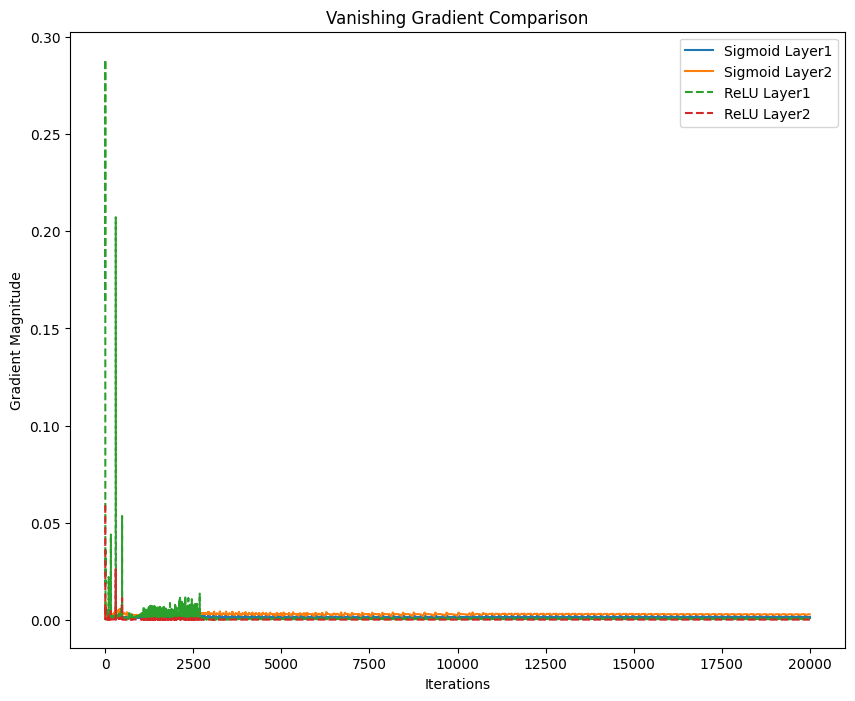

In [1]:
# =========================================================
# 🔥 VANISHING GRADIENT DEMO (FULL CODE - ONE CELL)
# =========================================================

# =========================
# 1. IMPORTS & SETUP
# =========================
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams['figure.figsize'] = (10, 8)

# =========================
# 2. GENERATE NON-LINEAR DATA (SPIRAL DATASET)
# =========================
N = 100  # points per class
D = 2    # input dimension
K = 3    # number of classes

X = np.zeros((N*K, D))
y = np.zeros(N*K, dtype='uint8')

for j in range(K):
    ix = range(N*j, N*(j+1))
    r = np.linspace(0.0, 1, N)
    t = np.linspace(j*4, (j+1)*4, N) + np.random.randn(N)*0.2
    X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
    y[ix] = j

# visualize dataset
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.Spectral)
plt.title("Spiral Dataset")
plt.show()

# =========================
# 3. ACTIVATION FUNCTIONS
# =========================
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_grad(x):
    return x * (1 - x)

def relu(x):
    return np.maximum(0, x)

# =========================
# 4. THREE-LAYER NETWORK FUNCTION
# =========================
def three_layer_net(NONLINEARITY, X, y, model, step_size=1e-0, reg=1e-3):

    # unpack parameters
    W1, b1 = model['W1'], model['b1']
    W2, b2 = model['W2'], model['b2']
    W3, b3 = model['W3'], model['b3']

    num_examples = X.shape[0]

    # track gradient magnitudes
    plot_array_1 = []
    plot_array_2 = []

    # =========================
    # TRAINING LOOP
    # =========================
    for i in range(20000):

        # =========================
        # FORWARD PROPAGATION
        # =========================
        if NONLINEARITY == 'RELU':
            hidden_layer = relu(np.dot(X, W1) + b1)
            hidden_layer2 = relu(np.dot(hidden_layer, W2) + b2)

        elif NONLINEARITY == 'SIGM':
            hidden_layer = sigmoid(np.dot(X, W1) + b1)
            hidden_layer2 = sigmoid(np.dot(hidden_layer, W2) + b2)

        scores = np.dot(hidden_layer2, W3) + b3

        # =========================
        # SOFTMAX + LOSS
        # =========================
        exp_scores = np.exp(scores)
        probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

        correct_logprobs = -np.log(probs[range(num_examples), y])
        data_loss = np.sum(correct_logprobs) / num_examples
        reg_loss = 0.5 * reg * (np.sum(W1*W1) + np.sum(W2*W2) + np.sum(W3*W3))
        loss = data_loss + reg_loss

        if i % 2000 == 0:
            print(f"[{NONLINEARITY}] Iter {i}, Loss: {loss:.4f}")

        # =========================
        # BACKPROPAGATION
        # =========================
        dscores = probs
        dscores[range(num_examples), y] -= 1
        dscores /= num_examples

        # output layer gradients
        dW3 = hidden_layer2.T.dot(dscores)
        db3 = np.sum(dscores, axis=0, keepdims=True)

        # =========================
        # BACKPROP - HIDDEN LAYER 2
        # =========================
        dhidden2 = dscores.dot(W3.T)

        if NONLINEARITY == 'RELU':
            dhidden2[hidden_layer2 <= 0] = 0
        else:
            dhidden2 *= sigmoid_grad(hidden_layer2)

        dW2 = hidden_layer.T.dot(dhidden2)
        db2 = np.sum(dhidden2, axis=0)

        # track gradient magnitude
        plot_array_2.append(np.mean(np.abs(dW2)))

        # =========================
        # BACKPROP - HIDDEN LAYER 1
        # =========================
        dhidden = dhidden2.dot(W2.T)

        if NONLINEARITY == 'RELU':
            dhidden[hidden_layer <= 0] = 0
        else:
            dhidden *= sigmoid_grad(hidden_layer)

        dW1 = X.T.dot(dhidden)
        db1 = np.sum(dhidden, axis=0)

        plot_array_1.append(np.mean(np.abs(dW1)))

        # =========================
        # ADD REGULARIZATION
        # =========================
        dW3 += reg * W3
        dW2 += reg * W2
        dW1 += reg * W1

        # =========================
        # PARAMETER UPDATE
        # =========================
        W1 += -step_size * dW1
        b1 += -step_size * db1
        W2 += -step_size * dW2
        b2 += -step_size * db2
        W3 += -step_size * dW3
        b3 += -step_size * db3

    # =========================
    # FINAL ACCURACY
    # =========================
    hidden_layer = relu(np.dot(X, W1) + b1) if NONLINEARITY=='RELU' else sigmoid(np.dot(X, W1) + b1)
    hidden_layer2 = relu(np.dot(hidden_layer, W2) + b2) if NONLINEARITY=='RELU' else sigmoid(np.dot(hidden_layer, W2) + b2)
    scores = np.dot(hidden_layer2, W3) + b3

    predicted_class = np.argmax(scores, axis=1)
    acc = np.mean(predicted_class == y)

    print(f"[{NONLINEARITY}] Final Accuracy: {acc:.2f}")

    return plot_array_1, plot_array_2

# =========================
# 5. INITIALIZE MODEL
# =========================
h = 50
h2 = 50

model = {
    'W1': 0.1 * np.random.randn(D, h),
    'b1': np.zeros((1, h)),
    'W2': 0.1 * np.random.randn(h, h2),
    'b2': np.zeros((1, h2)),
    'W3': 0.1 * np.random.randn(h2, K),
    'b3': np.zeros((1, K)),
}

# =========================
# 6. TRAIN WITH SIGMOID
# =========================
sig_1, sig_2 = three_layer_net('SIGM', X, y, model.copy())

# =========================
# 7. TRAIN WITH RELU
# =========================
relu_1, relu_2 = three_layer_net('RELU', X, y, model.copy())

# =========================
# 8. PLOT RESULTS
# =========================
plt.figure()

plt.plot(sig_1, label="Sigmoid Layer1")
plt.plot(sig_2, label="Sigmoid Layer2")

plt.plot(relu_1, '--', label="ReLU Layer1")
plt.plot(relu_2, '--', label="ReLU Layer2")

plt.title("Vanishing Gradient Comparison")
plt.xlabel("Iterations")
plt.ylabel("Gradient Magnitude")
plt.legend()
plt.show()